# DP data parallel

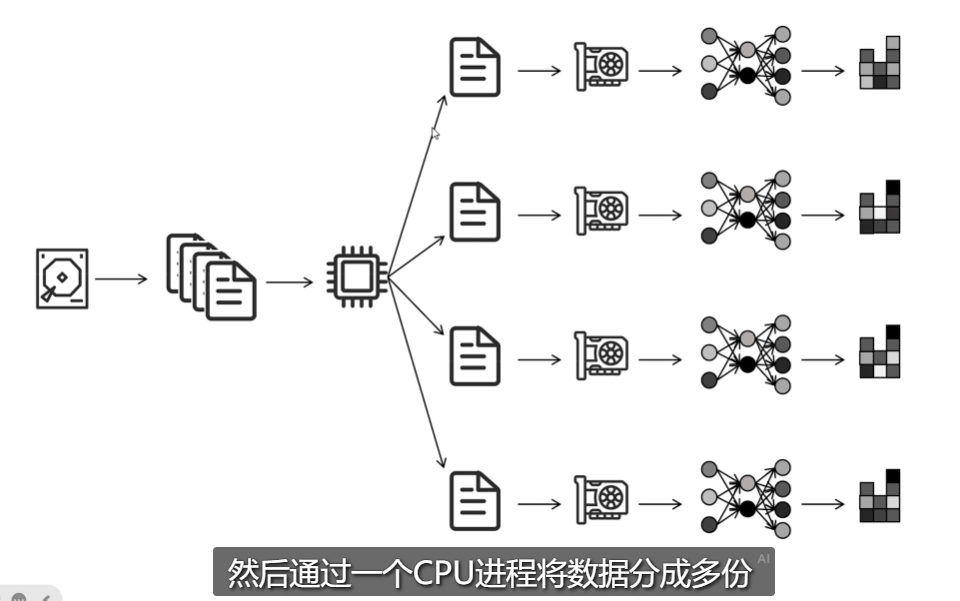

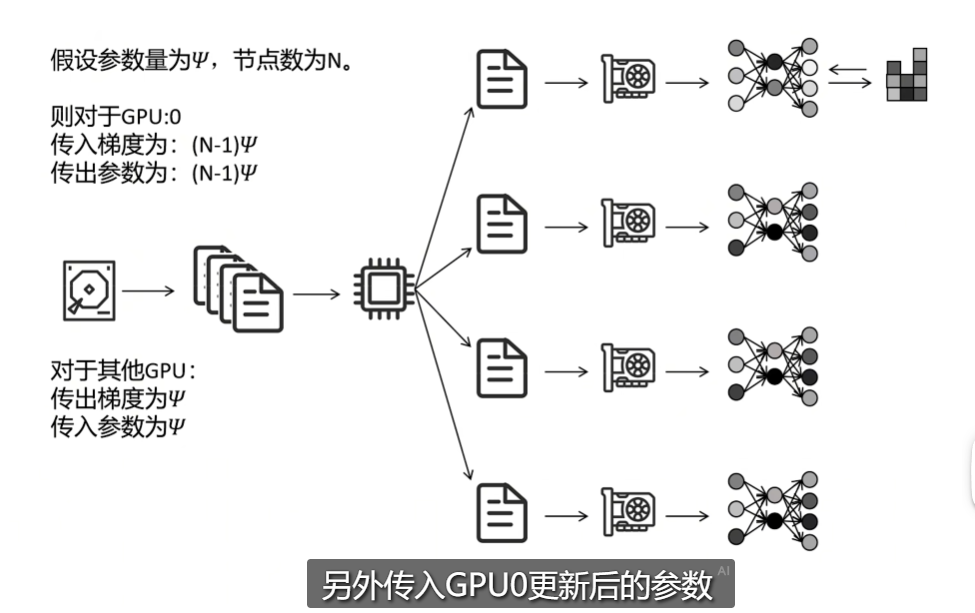

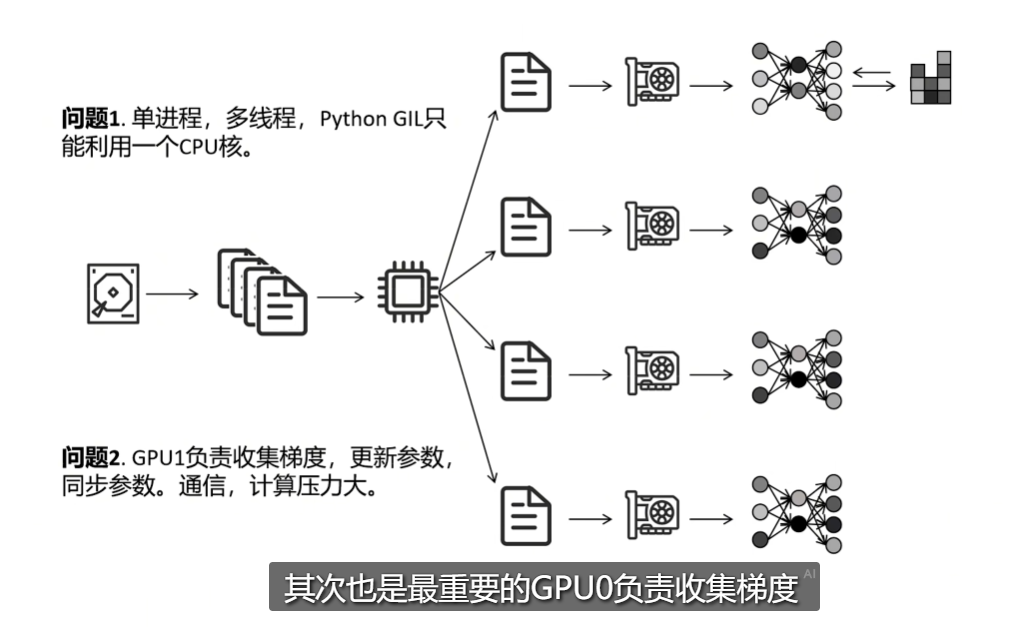

每个GPU独立进行梯度计算，然后传输到GPU0进行平均 然后结果再广播到各个GPU的网络中  依次循环

单进程多线程  只能用一个CPU

GPU0压力大

# DDP Distributed data parallel
## ring-allreduce----scatter reduce
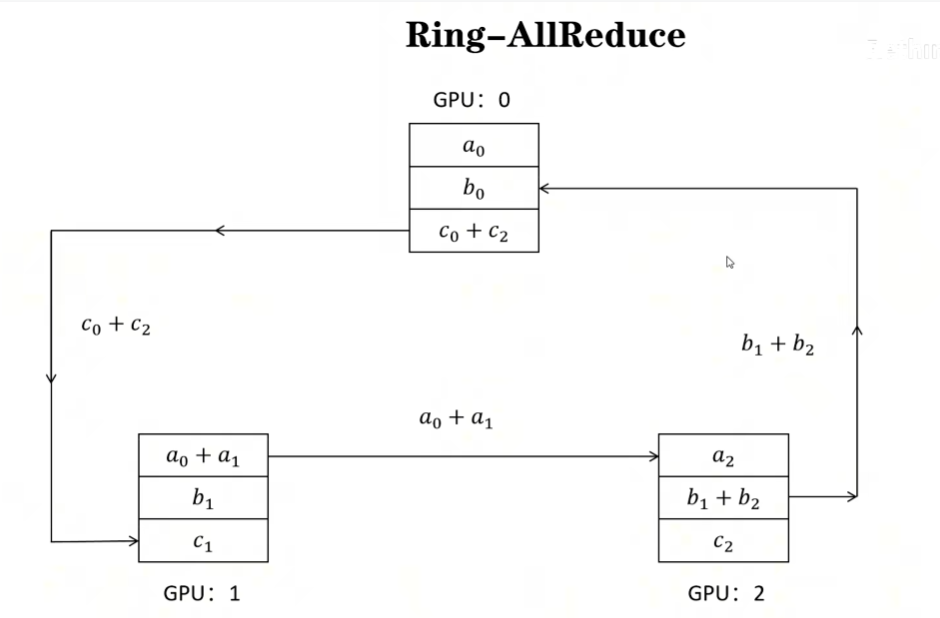

每个对应的梯度进行传播，比如a0传播到a1相加，第二步再让a0+a1的结果传播到a2。让所有GPU都保持有输入和输出。最终让每一个GPU都有一个梯度的完整的累计和

## ring-allreduce----all gather
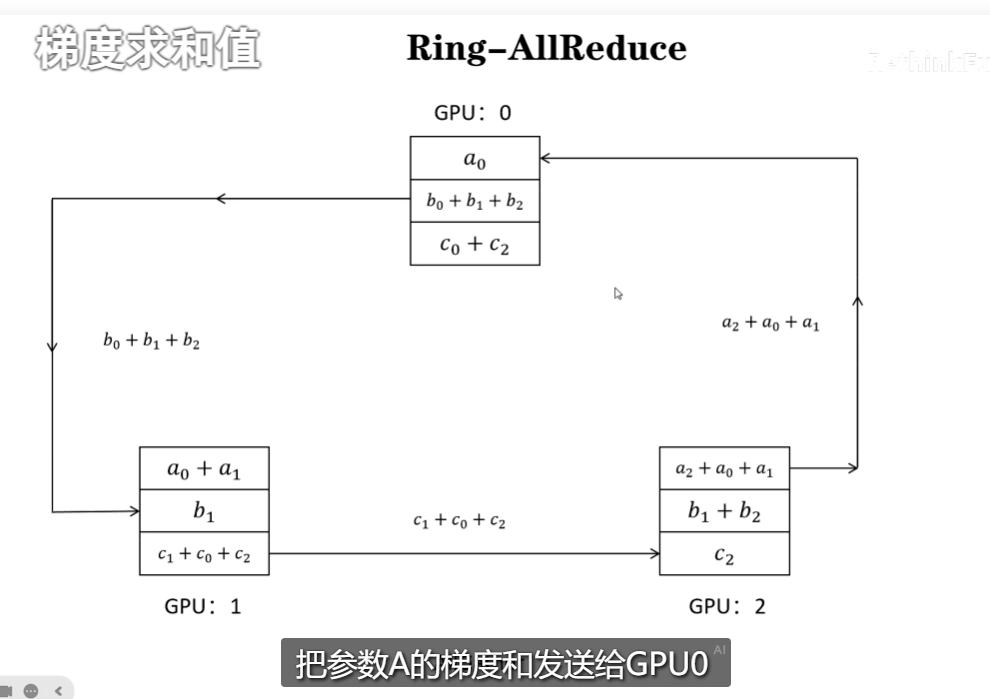
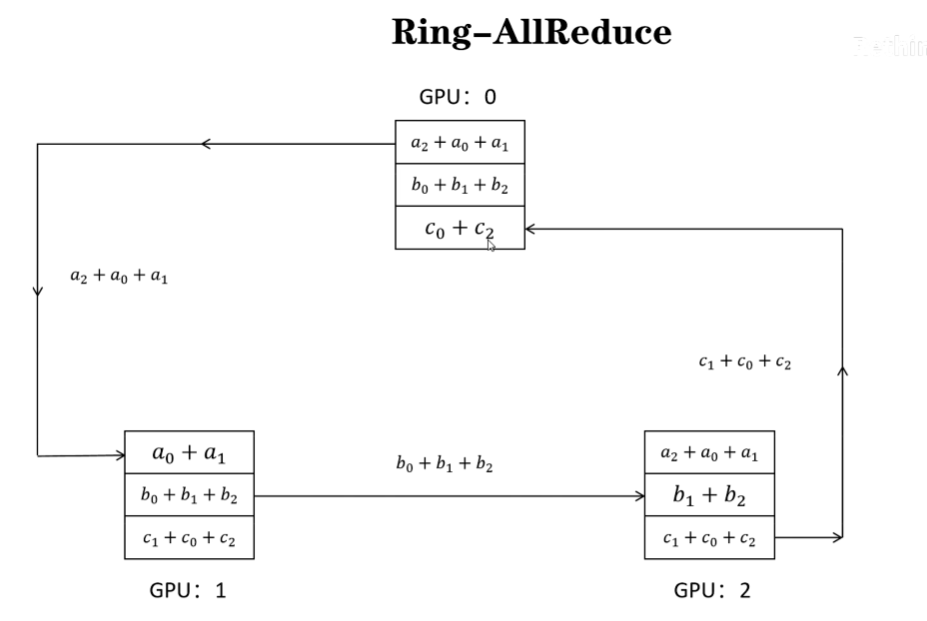

所有GPU都有所有的梯度和。同时发送和接受，最大限度利用每个显卡的上下行带宽。

多进程多线程
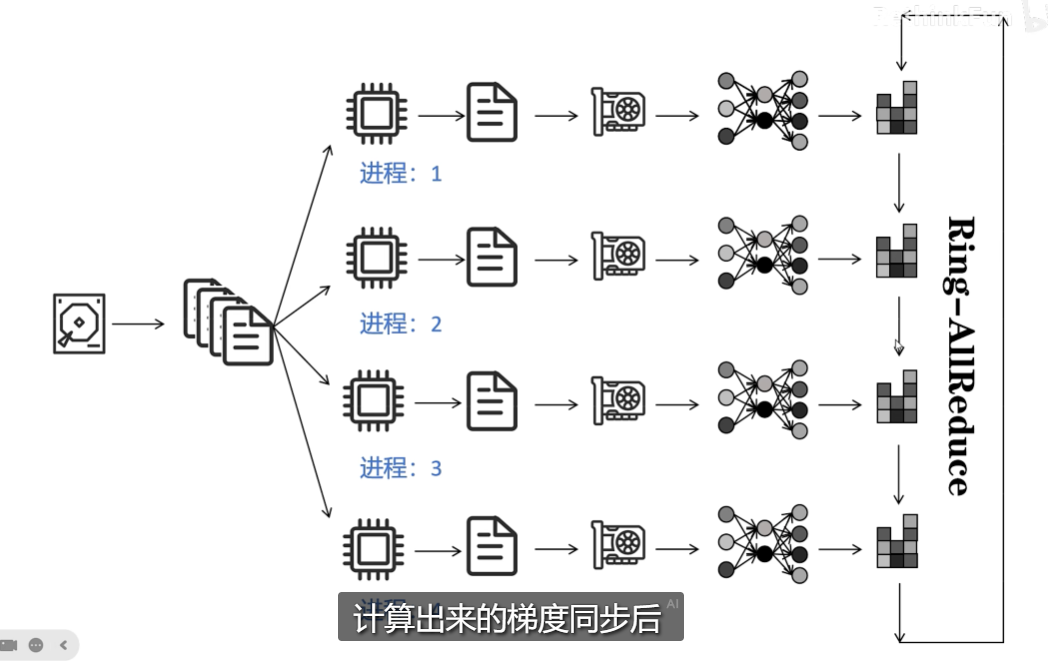
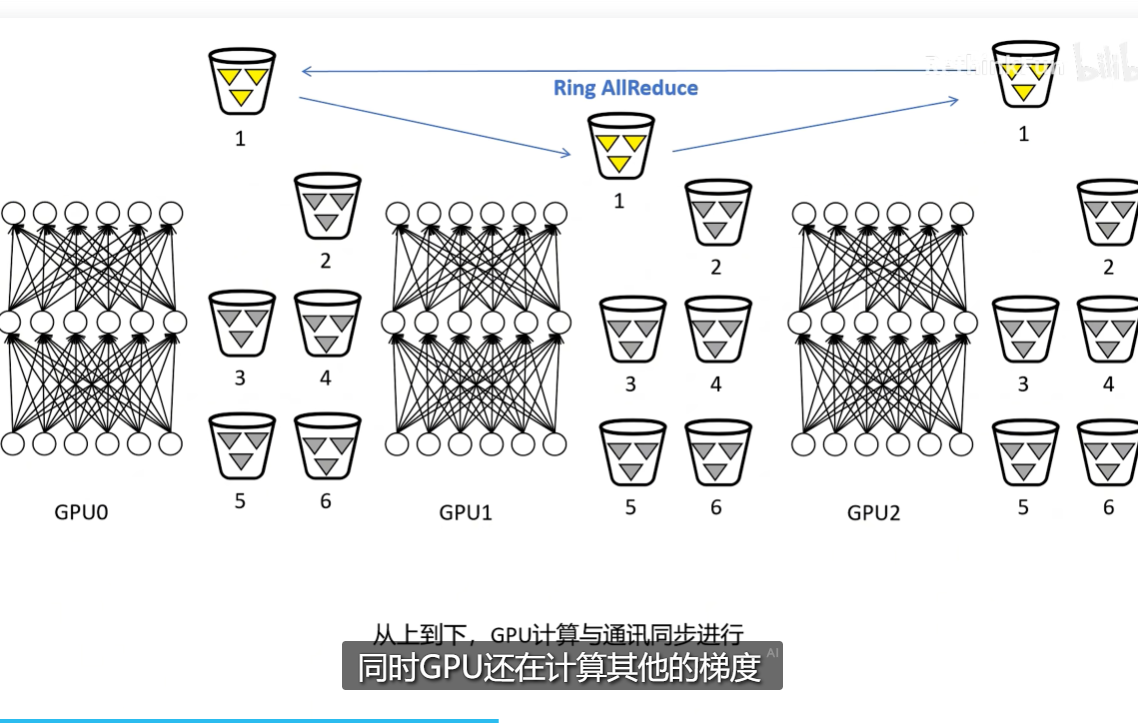
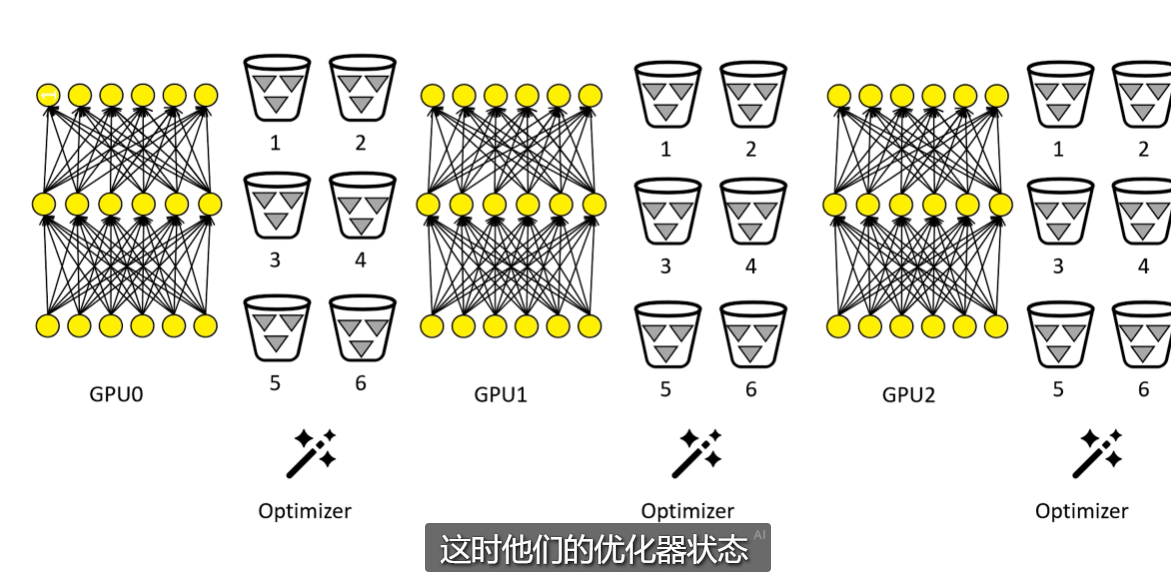
不同的数据得到的梯度不同，ringallreduce得到所有的梯度的总和，然后所有梯度就相同了，然后所有的进程各自优化器进行优化（注意DP只有GPU0有优化器）

所有的进程的优化器和网络参数的初始值都是相同的  梯度平均以后也是相同的  所以每个进程其实是相同的网络 但是都处理一部分数据

收集满一个桶才ringallreduce（不然一个梯度就变换太奢侈了），注意先被收集的上层的梯度，因为是反向的。

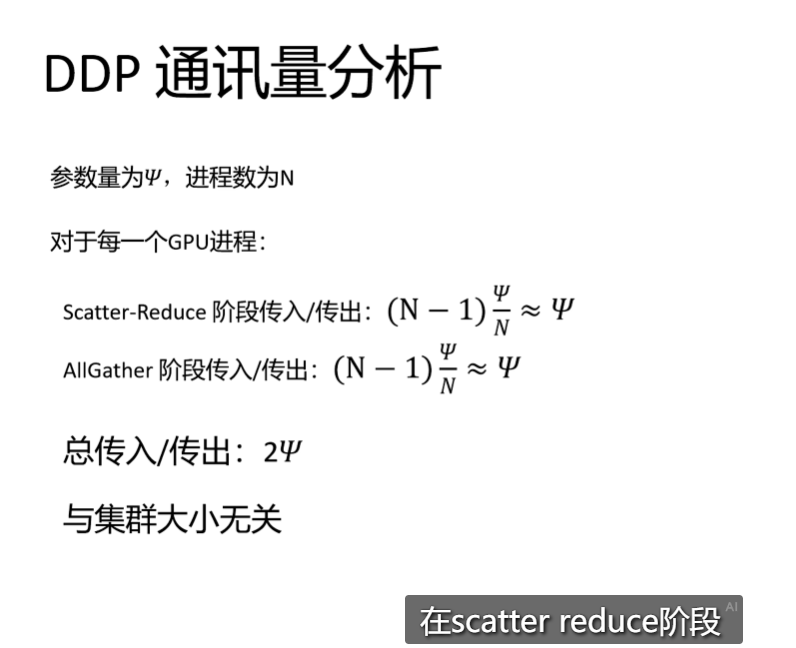

# deepspeed zero
## deepspeed zeroV1
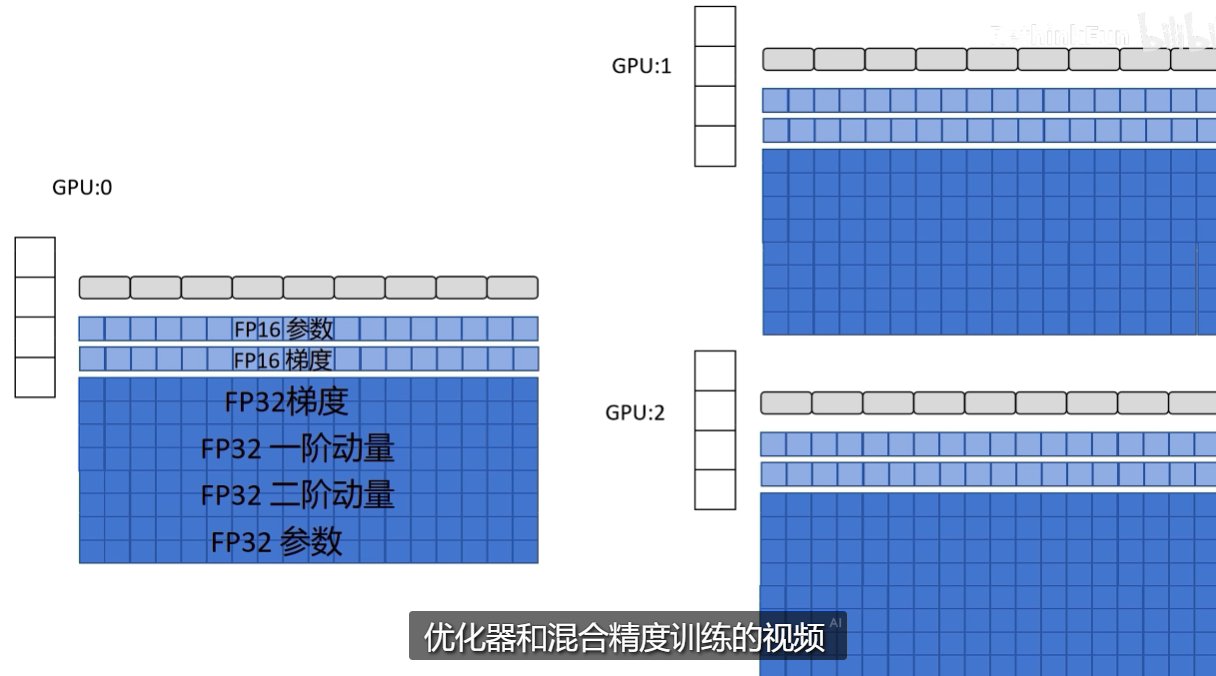

浅蓝是网络的参数。深蓝是优化器的参数。每个优化器是相同的，但是显存占用太大，所有可以拆分

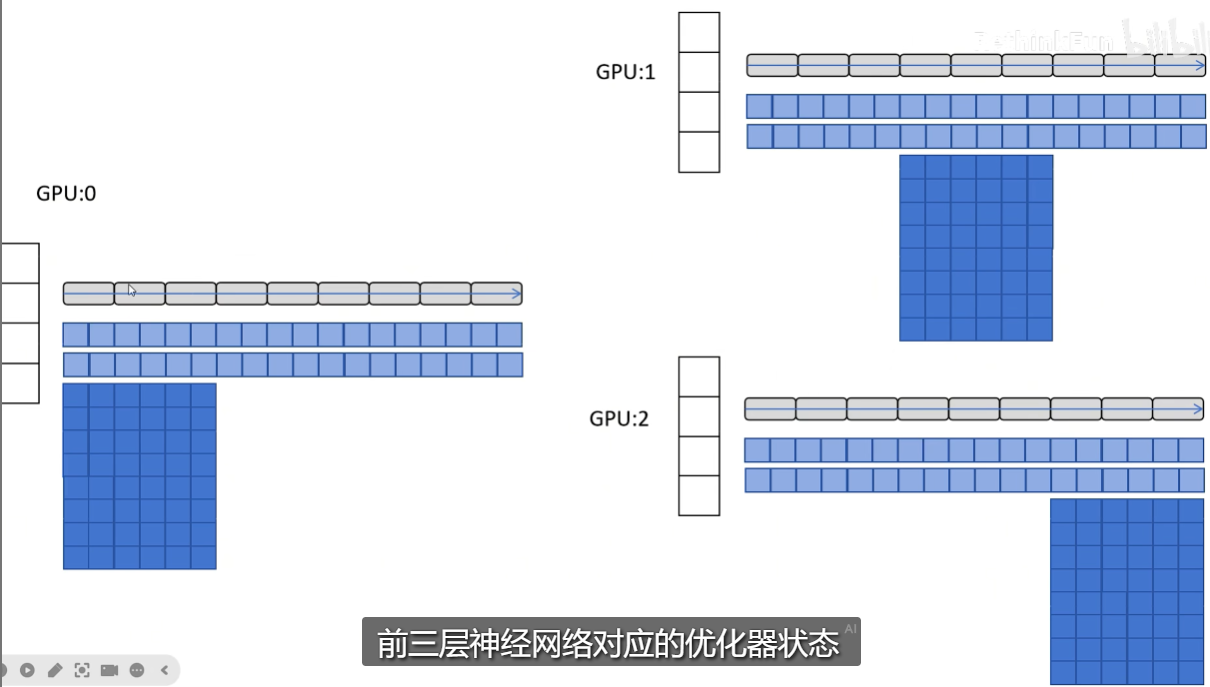

优化器的层GPU0前三层 GPU1中间三层....

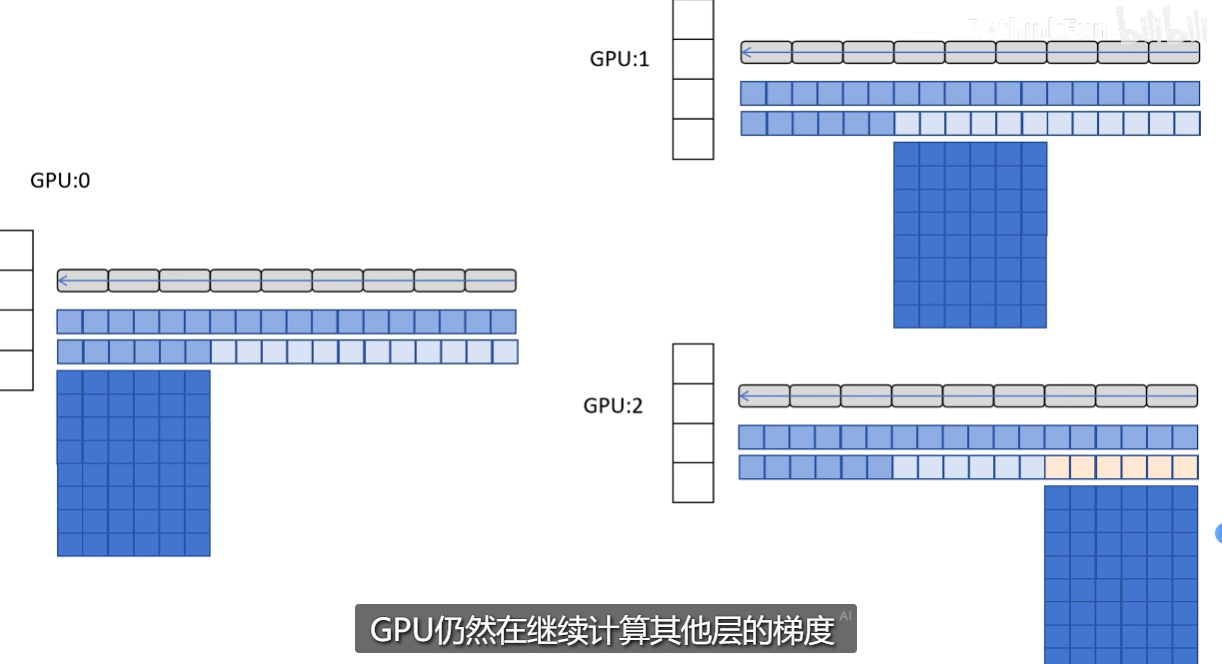

梯度计算出加在一起求均值给对应的优化器的位置。传输的同时仍然在计算梯度。然后更新对应优化器，优化器再更新对应的网络参数，然后各个层更新后的参数广播给别的GPU
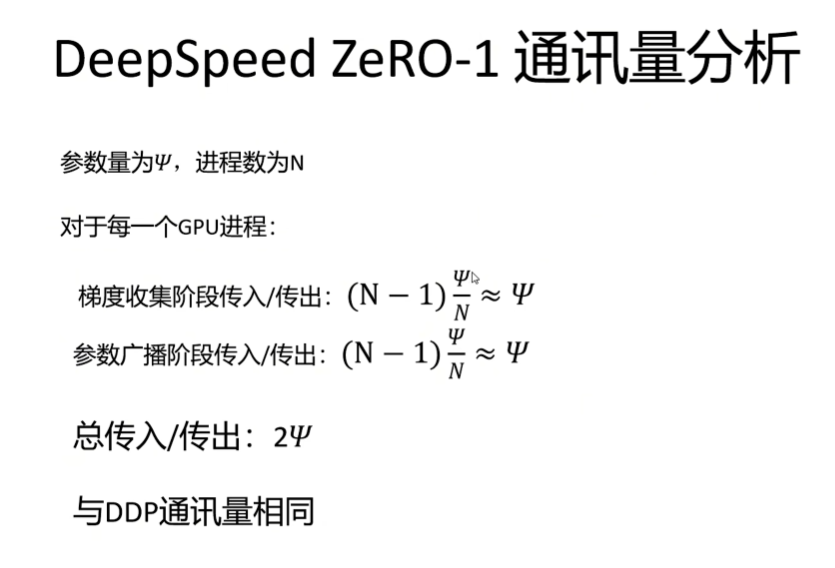


## deepseek zeroV2
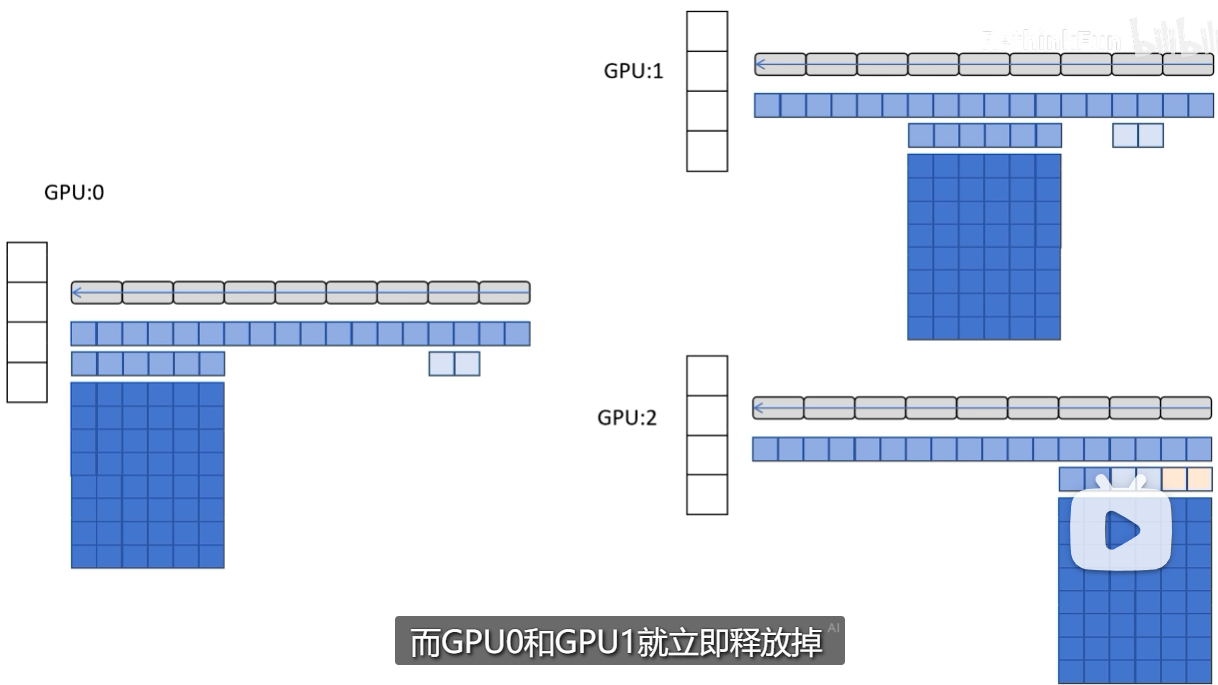
反向传播计算出梯度传播以后就立即释放掉。因为优化器分割以后 其实只需要对应部分的梯度
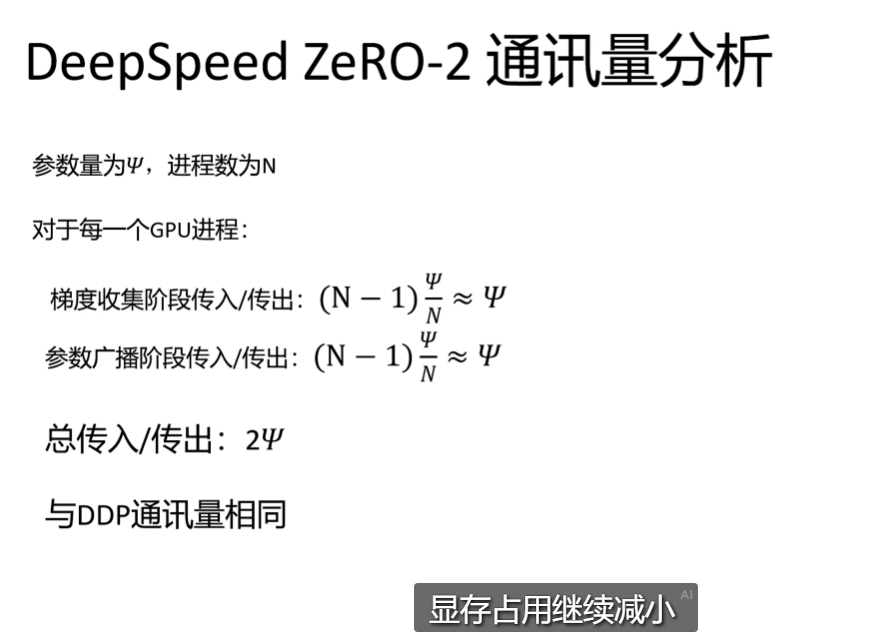

## deepseek zeroV3
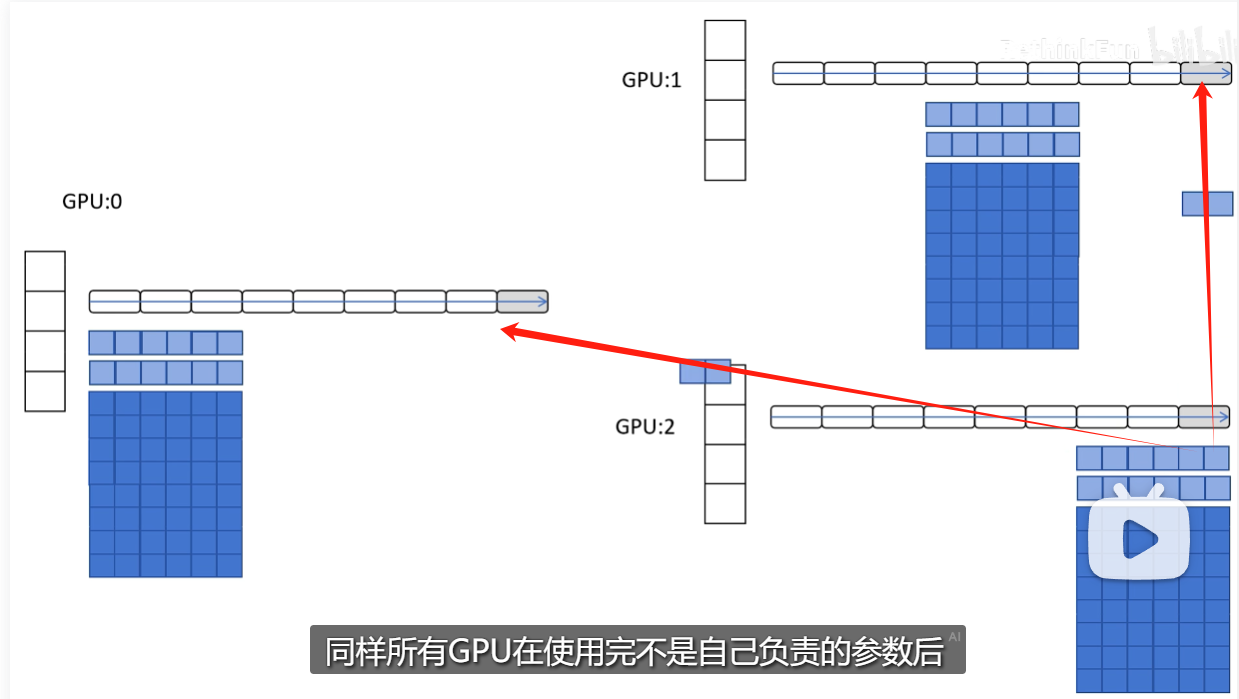
对参数也分割，这样前向后向都需要参数进行广播 计算结束以后释放
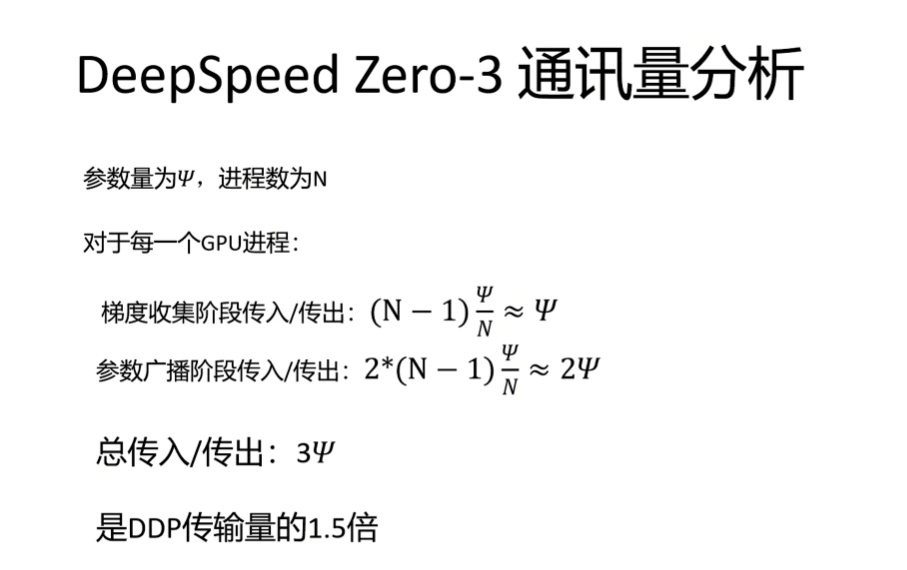

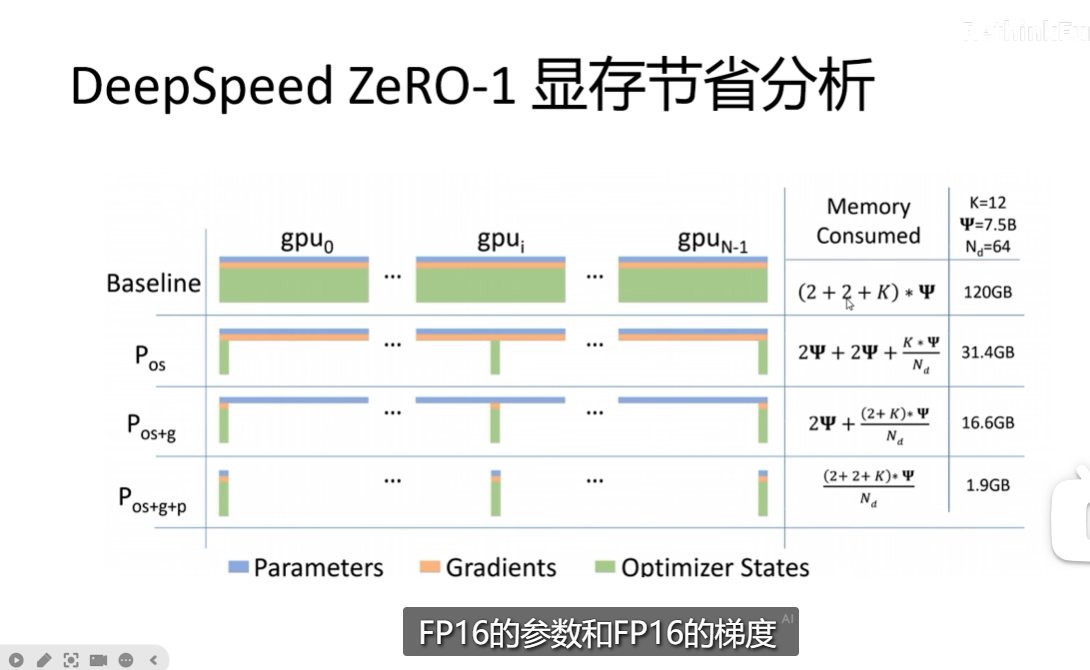
2+2是参数和精度各占2个字节  K是优化器占的字节数  fp16  2个字节

一般用zero2 因为它没有增加通信量 而且大大减少了显存占用